# Práctica computacional 1: Transcriptómica comparativa

<a href="https://colab.research.google.com/github/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/master/notebooks/ComputerLab1_SingleCellGenomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El sueño se controla por dos mecanismos:
El sistema circadiano y el sistema homeostático del sueño. El reloj circadiano decide a qué hora sentimos sueño y funciona gracias a un ciclo de activación y desactivación de unos genes especiales llamados “**genes reloj**”. <br> <br>
A nivel celular, este reloj en animales se concentra en neuronas que actúan como marcapasos: el núcleo supraquiasmático (SCN) en los mamíferos y unas 150 neuronas reloj en la mosca *Drosophila*. <br>
Pero ¿qué hay de otras especies? <br> <br>
En esta práctica nuestra misión sera buscar neuronas reloj en el cerebro de una araña.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Especificar nuestro directorio de trabajo
%cd /content/drive/MyDrive/CdeCMx2025_GTO4/
!ls

/content/drive/MyDrive/CdeCMx2025_GTO4
'GTO4 abstract.gdoc'
'Lecturas y materiales'
'Planeacion de Curso de Verano de Cronbiologia comparativa.docx'
 Presentaciones
 Programa_GTO4_CdeCMx2025.gsheet
 Tutoriales


In [4]:
# Instalar librerias con funciones utiles para nuestro analisis y visualizacion
!pip install scanpy
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 36.2 MB/s eta 0:00:00


In [5]:
# Cargar librerias
import scanpy as sc
import numpy as np
import anndata as ad
import os

El dataset que ocuparemos tiene 5 muestras, cada una de ellas tiene 3 archivos:


*   barcodes: un identificador para cade celula.
*   features: los nombres de los genes.
*   matrix: la matriz con los niveles de expresion.



In [6]:
# Leer los datos
samples = {
    "F1": "/content/drive/MyDrive/CdeCMx2025_GTO4/Tutoriales/data/singlecell_spider/F1",
    "F2": "/content/drive/MyDrive/CdeCMx2025_GTO4/Tutoriales/data/singlecell_spider/F2",
    "F3": "/content/drive/MyDrive/CdeCMx2025_GTO4/Tutoriales/data/singlecell_spider/F3",
    "M1": "/content/drive/MyDrive/CdeCMx2025_GTO4/Tutoriales/data/singlecell_spider/M1",
    "M2": "/content/drive/MyDrive/CdeCMx2025_GTO4/Tutoriales/data/singlecell_spider/M2",
}
adatas = {}

for sample_id, filepath in samples.items():
    sample_adata = sc.read_10x_mtx(filepath)
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 40233 × 19195
    obs: 'sample'


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 1. Control de calidad (QC) y preprocesamiento

Una vez que tenemos nuestros datos juntos, podemos calcular metrics comunes de control de calidad e inspeccionar en violin plots algunas de las metricas como:

*   el numero de genes expresados en la matriz de cuentas
*   las cuentas totales por celula



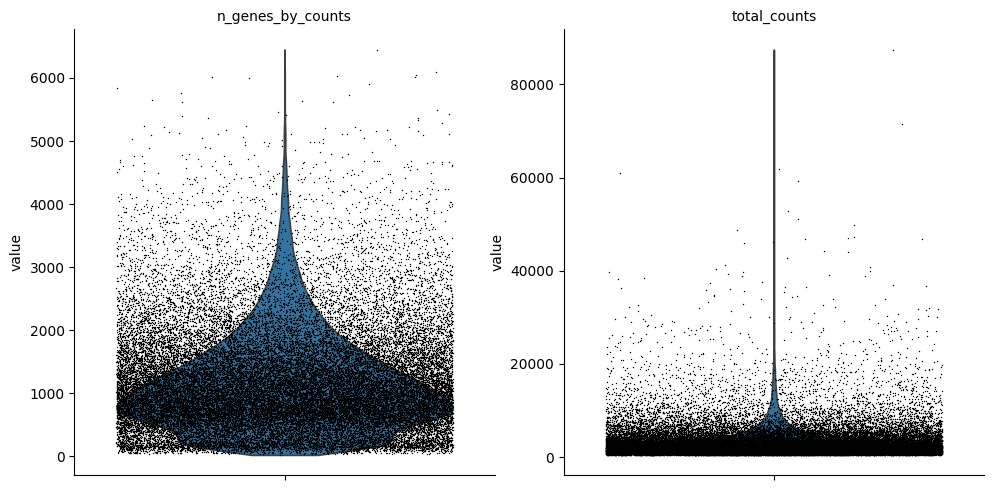

In [10]:
sc.pp.calculate_qc_metrics(
    adata, inplace=True, log1p=True
)

sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts'],
    jitter=0.4,
    multi_panel=True,
    rotation=45,
)

Adicionalmente, es util inspeccionar ambas metricas en un scatter plot:

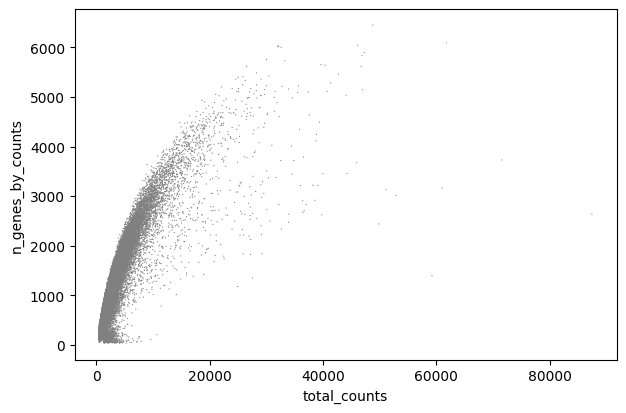

In [11]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

Basándose en los gráficos de las métricas de control de calidad, se podrían eliminar las células que tengan demasiados genes mitocondriales expresados o un número excesivo de conteos totales, fijando umbrales manuales o automáticos. <br/><br/>
Sin embargo, a veces lo que parece ser una mala métrica de calidad puede estar motivado por procesos biológicos reales, de modo que recomendamos comenzar con una estrategia de filtrado muy permisiva y revisarla más adelante. <br/><br/>
Por ello, en este punto solo filtramos las células con menos de 100 genes expresados y los genes detectados en menos de 5 células.<br/><br/>
Además, es importante señalar que, para conjuntos de datos con múltiples muestras, el control de calidad debe realizarse idealmente de forma individual para cada muestra, ya que los umbrales pueden variar sustancialmente entre lotes.

In [12]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=5)

#### 🔧    Actividad: Juega con los filtros, vuelve a correr la celda y observa cuantas celulas quedan.

In [15]:
# Ajusta los valores
min_genes = 200
max_genes = 4000
min_counts = 5

# Applicar los filtros
adata_qc = adata[
    (adata.obs['n_genes_by_counts'] >= min_genes) &
    (adata.obs['n_genes_by_counts'] <= max_genes) &
    (adata.obs['total_counts']      >= min_counts),
    :
].copy()

print(f'No. de celulas despues de QC: {adata_qc.n_obs:,}')

No. de celulas despues de QC: 37,653


Como siguiente paso, ejecutamos un algoritmo para  **detectar *doublets*** (casos en los que dos células quedan atrapadas juntas y se secuencian como si fueran una sola).<br/>
Detectar estos *doublets* es muy importante porque, si no los eliminamos, los perfiles de dos células diferentes se mezclan y pueden:<br/>


*   confundir la clasificación de tipos celulares
*   generar “falsos” grupos en el análisis de clústeres
*   alterar la expresión promedio de los genes y, en consecuencia, afectar todo análisis posterior (diferencial de expresión, trayectorias, inferencia de regulones, etc.)


In [16]:
sc.pp.scrublet(adata, batch_key="sample")

El siguiente paso de preprocesamiento es la **normalización**. Este paso asegura que asegura que las posteriores etapas de análisis se basen en señal biológica auténtica y no en artefactos de secuenciación.

In [17]:
# Normalizar a la mediana de cuentas totales
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## 2. Genes informativos y reduccion de dimensiones

Ahora filtraremos los genes mas informativos para mantener nuestro analisis rapido y libre de ruido.

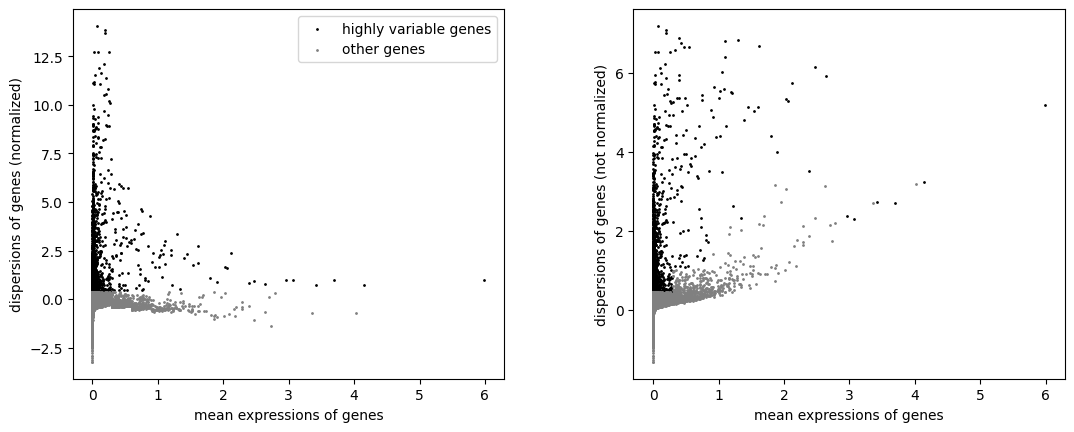

In [18]:
# Identificar genes mas informativos
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

En conjunto, estos tres comandos transforman datos brutos y de alta dimensión en una representación clara, útil para explorar la biología y comunicar resultados.<br/>


*   **PCA**:
Condensa la información más relevante.
Elimina redundancias y ruido técnico.
Hace que los siguientes algoritmos trabajen sobre un espacio pequeño y manejable.
*   **Vecinos (k-NN)**:Define la “red social” de cada célula en el espacio reducido.
Sobre este grafo se basan algoritmos de clustering (Leiden/Louvain) y métodos como UMAP o diffusion maps.

*   **PCA**:Provee una visualización intuitiva donde los tipos celulares forman “nubes” o clústeres.
Permite detectar fácilmente muestras mal corregidos, doublets no filtrados o subpoblaciones celulares nuevas.

In [19]:
# Reduccion de dimensiones
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

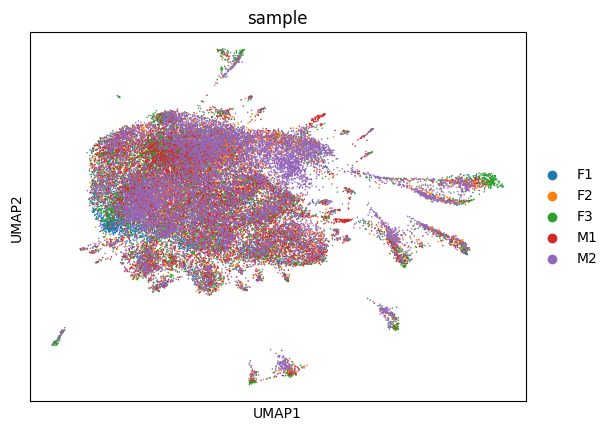

In [20]:
# Visualizacion en 2D
sc.pl.umap(
    adata,
    color="sample",
    size=5
)

Aunque los datos analizados en este tutorial provienen de dos muestras distintas, solo observamos un efecto de lote menor, por lo que podemos continuar con el agrupamiento y la anotación de nuestros datos.<br/>
Si al inspeccionar UMAPs detectas efectos de lote más pronunciados, puede ser útil integrar las muestras y aplicar una corrección/integración de lote.

## 3. Clustering y genes marcadores

Ahora podemos agrupar nuestras celulas con base en su similitud de patrones de expresion. Proboremos 3 distintos niveles de resolucion.

In [21]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

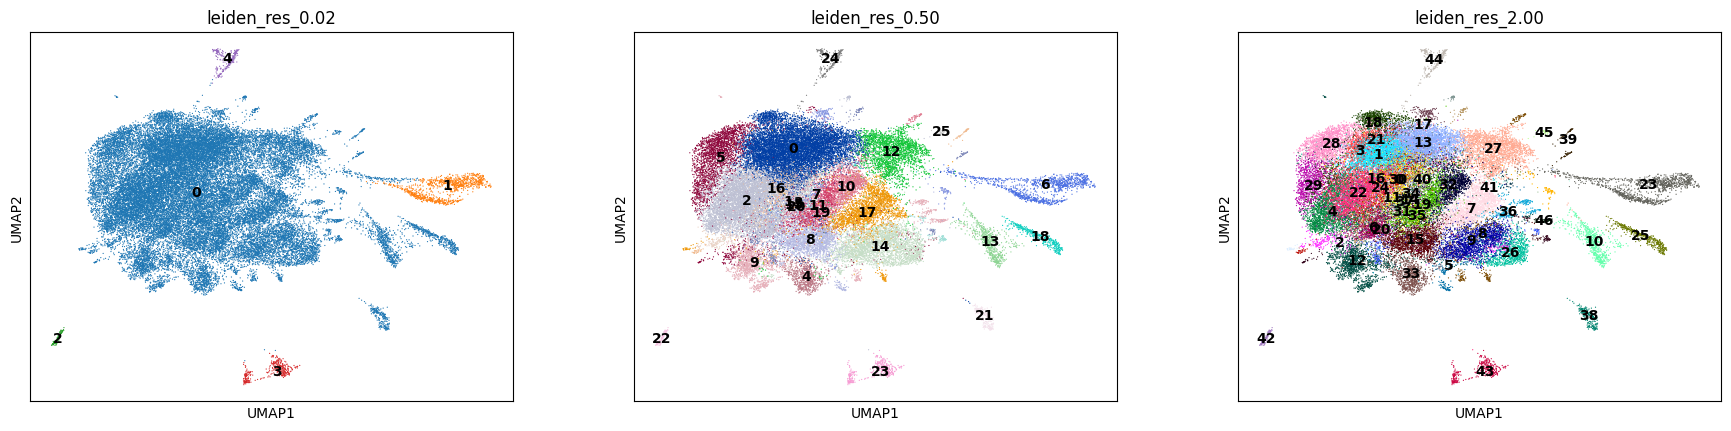

In [22]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

Vamos a identificar los genes que **distinguen** a cada clúster. Usando la prueba estadistica predeterminada (`t‑test_overestim_var`).

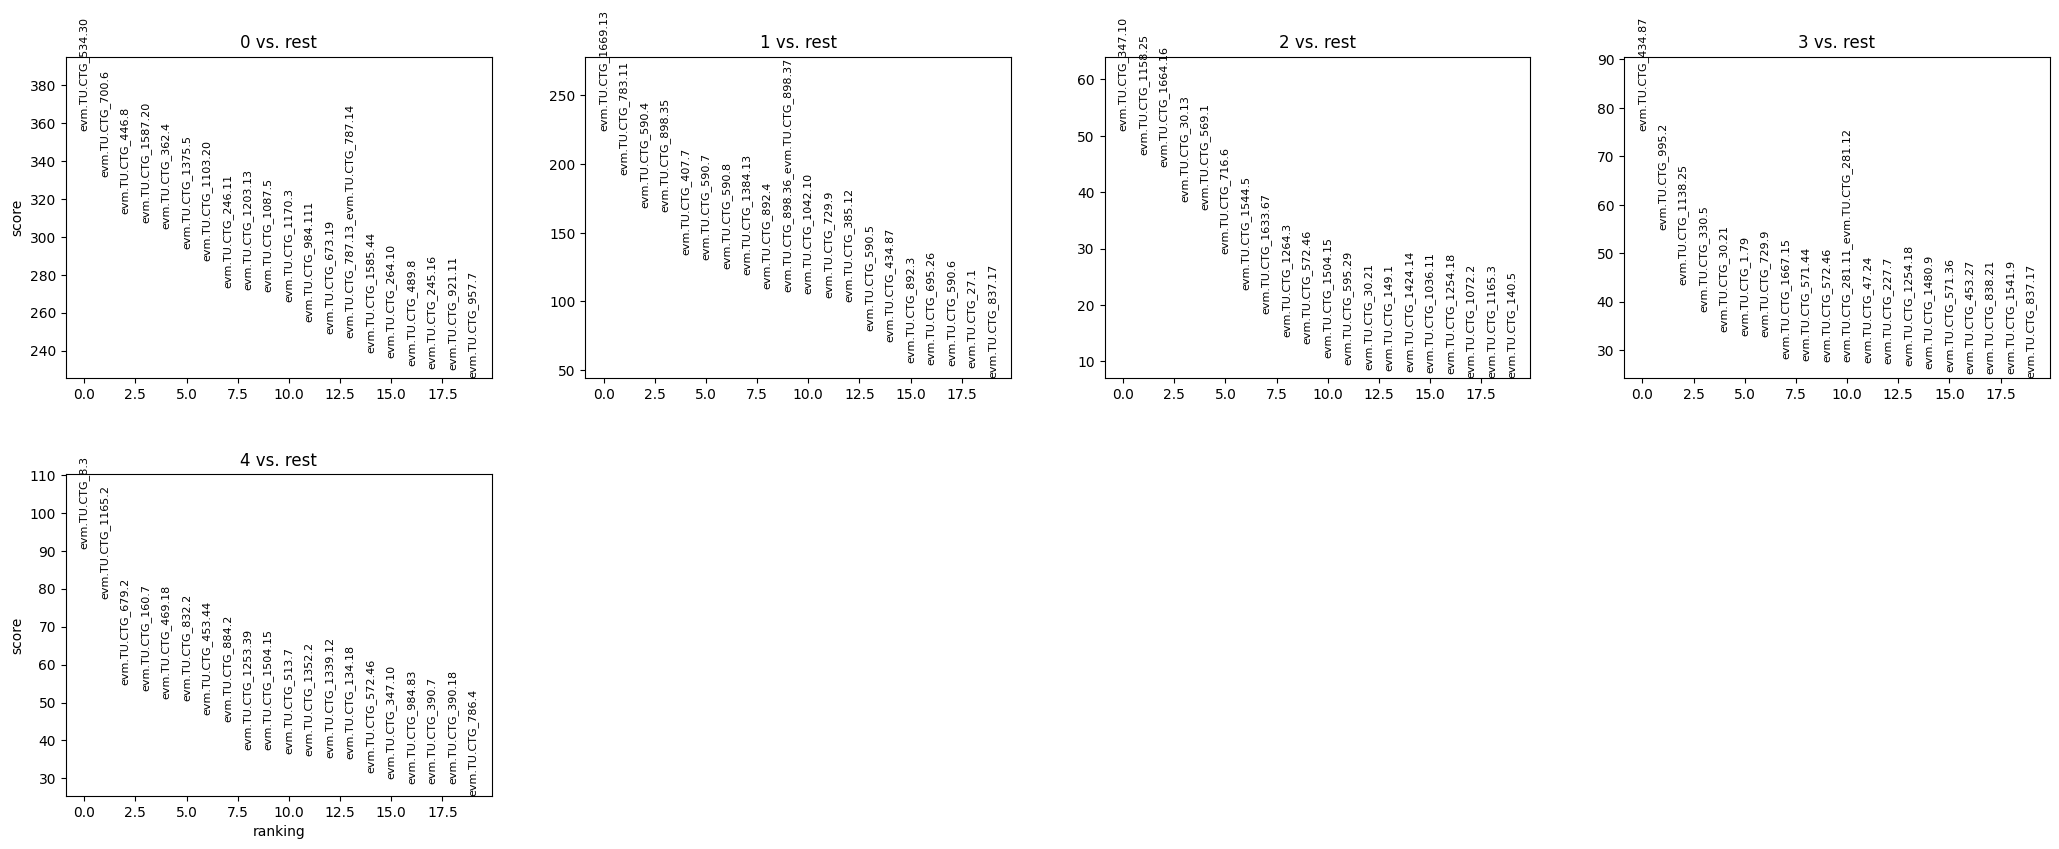

In [30]:
sc.tl.rank_genes_groups(adata, 'leiden_res_0.02', method='t-test_overestim_var', n_genes=50)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

🔍 Finalmente visualizaremos los genes que identifican a cada clúster.

dendrogram data not found (using key=dendrogram_leiden_res_0.02). Running `sc.tl.dendrogram` with default parameters. For fine tuning it is recommended to run `sc.tl.dendrogram` independently.


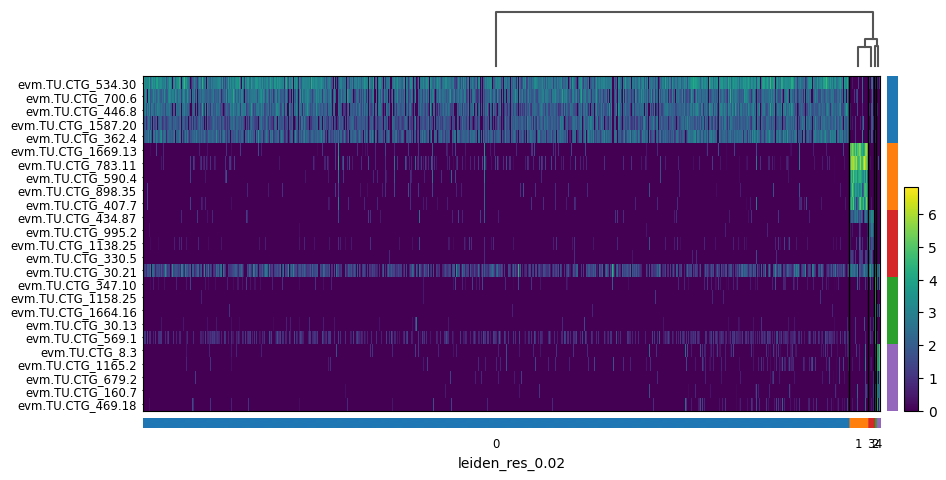

In [31]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    groupby='leiden_res_0.02',
    show_gene_labels=True,
    cmap='viridis',
    swap_axes=True,
)

#### 🔧    Actividad: Juega con las distintas resoluciones, explora distintos clusters, investiga acerca de la biologia los genes diferencialmente expresados.

Top genes for cluster 1: ['evm.TU.CTG_1669.13', 'evm.TU.CTG_783.11', 'evm.TU.CTG_590.4', 'evm.TU.CTG_898.35', 'evm.TU.CTG_407.7']


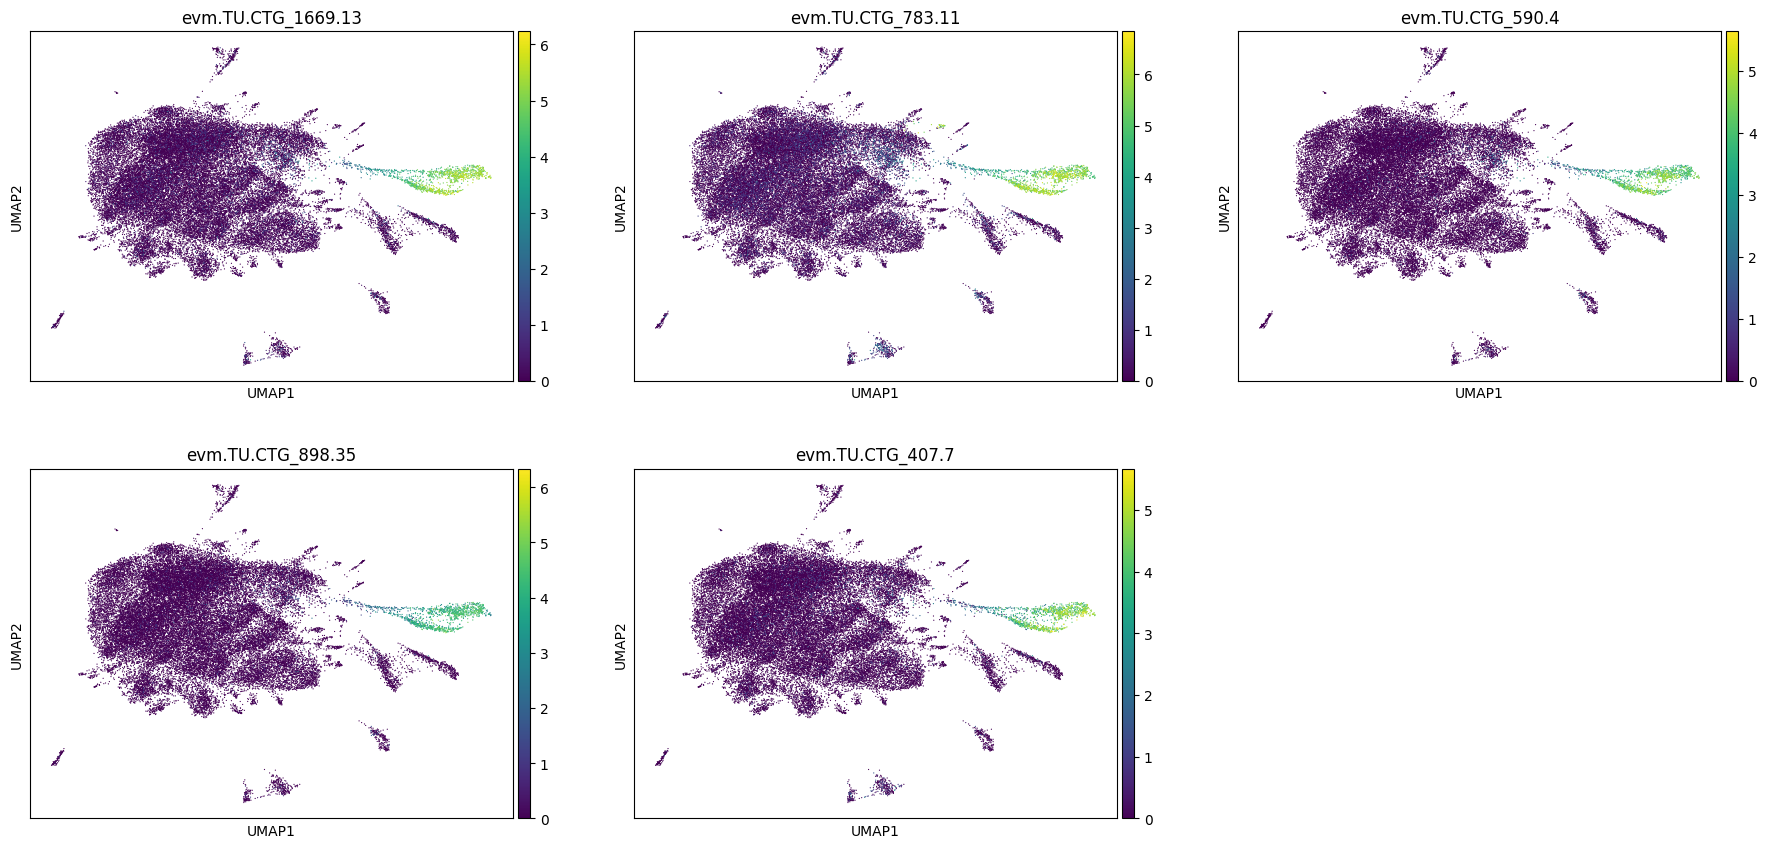

In [45]:
cluster_id = '1'   # pueba con otros clusters

import pandas as pd

# Extrae top 5 genes para el clúster elegido
top_genes = pd.DataFrame(
    {
        g: adata.uns['rank_genes_groups']['names'][g][:5]
        for g in adata.obs['leiden_res_0.02'].cat.categories
    }
).loc[:, cluster_id].tolist()

print(f'Top genes for cluster {cluster_id}:', top_genes)

# Visualiza expresión de los genes por celula
sc.pl.umap(
    adata,
    color=top_genes,   # lista de genes
    ncols=3,
)

## 4. Neuronas reloj

Ahora que hemos identificado clusters de celulas podemos buscar poblaciones neuronales previamente identificadas en otras especies. <br/>
Previamente se han identificado las neuronas reloj en Drosophila con base la expresion de genes circadianos claves y se ha visto que ademas se encuentran expresados en algunas poblaciones de glia https://www.nature.com/articles/s41593-023-01549-4 <br/>

![](https://github.com/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/main/media/41593_2023_1549_Fig2_HTML.png?raw=true)


🔍 Finalmente podemos hacer un diccionario con nuestros genes circadianos favoritos y su expresion en las distintas poblaciones celulares del cerebro de la araña.

In [46]:
marker_genes = {
    "Neuronas reloj": ["evm.TU.CTG_631.23", # Tim
                       "evm.TU.CTG_1609.6",
                       "evm.TU.CTG_170.4",
                       "evm.TU.CTG_1599.16",
                       "evm.TU.CTG_1315.33",
                       "evm.TU.CTG_262.11"]
}

🔍 ¿Observas un patron similar?

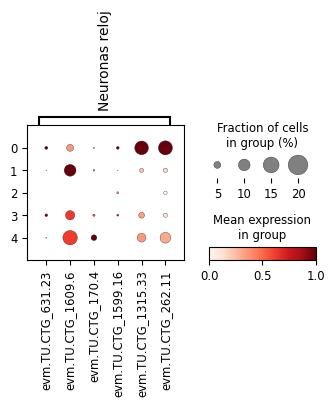

In [47]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

## 🚀 ¿Que sigue?

El cielo es el limite, lo que hemos realizado es solo el comienzo del analisis, nuestros resultados pueden ser la base de otros estudios como veremos en la siguiente practica.
<br/><br/>
¿Se te ocurren otras preguntas o ideas que podamos contestar con este tipo de datos?